<a href="https://colab.research.google.com/github/kazi-amir/ml-learning/blob/main/pytorch-5-projects/5-text-classification-news-headline-sarcasm-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. Text Classification - Sarcasm Detection (News Headline)

In [1]:
!pip install opendatasets --quiet

In [2]:
!pip install legacy-cgi --quiet

In [3]:
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/rmisra/news-headlines-dataset-for-sarcasm-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kaziamirhamza
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:01<00:00, 2.59MB/s]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer, AutoModel

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
data_df = pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json", lines=True)
data_df.shape

(26709, 3)

In [8]:
data_df.dropna(inplace=True)
data_df.drop_duplicates(inplace=True)
data_df.drop(['article_link'], inplace=True, axis=1)
data_df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [9]:
data_df.shape

(26708, 2)

In [10]:
X_train, X_val_test, y_train, y_val_test = train_test_split(np.array(data_df['headline']), np.array(data_df['is_sarcastic']), test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)

In [11]:
X_train.shape, X_val.shape, X_test.shape

((18695,), (4006,), (4007,))

In [12]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased", device_map="auto")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
class CustomDataset(Dataset):
  def __init__(self, X, Y):
    self.X = [tokenizer(x,
                        max_length = 100,
                        truncation=True,
                        padding="max_length",
                        return_tensors="pt").to(device)
                        for x in X
              ]
    self.Y = torch.tensor(Y, dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

In [14]:
train_data = CustomDataset(X_train, y_train)
val_data = CustomDataset(X_val, y_val)
test_data = CustomDataset(X_test, y_test)

In [15]:
LR = 0.0001
BATCH_SIZE = 32

In [16]:
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

In [17]:
class TextClassifier(nn.Module):
  def __init__(self, bert):
    super().__init__()

    self.bert = bert
    self.dropout = nn.Dropout(0.25)
    self.linear1 = nn.Linear(768, 384)
    self.linear2 = nn.Linear(384, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, input_ids, attention_mask):
    populated_output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)[0][:, 0]
    output = self.linear1(populated_output)
    output = self.dropout(output)
    output = self.linear2(output)
    output = self.sigmoid(output)

    return output

In [18]:
for param in bert_model.parameters():
  param.requires_grad = False

model_0 = TextClassifier(bert_model).to(device)
model_0

TextClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [19]:
# Loss Function
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(model_0.parameters(), lr=LR)

## Model Training Loop

In [20]:
train_loss_per_epoch = []
train_acc_per_epoch = []
val_loss_per_epoch = []
val_acc_per_epoch = []

epochs = 10

for epoch in range(epochs):
  total_train_loss = 0
  total_train_acc = 0
  total_val_loss = 0
  total_val_acc = 0

  # Model in Training Mode
  model_0.train()
  for idx, data in enumerate(train_dataloader):
    x, y = data
    x = x.to(device)
    y = y.to(device)

    # Forward Pass
    predictions = model_0(x['input_ids'].squeeze(1), x['attention_mask'].squeeze(1)).squeeze(1)

    # Calculate the loss and Acc
    batch_loss = criterion(predictions, y)
    total_train_loss += batch_loss.item()
    batch_acc = accuracy_score(y.cpu().detach().numpy(), torch.round(predictions).cpu().detach().numpy())
    total_train_acc += batch_acc

    # Optimizer Zero Grad
    optimizer.zero_grad()

    # Backward Pass
    batch_loss.backward()

    # Optimizer Step
    optimizer.step()

  # Model in Evaluation Mode
  with torch.inference_mode():
    # Evaluation Mode
    model_0.eval()

    for idx, data in enumerate(val_dataloader):
      x, y = data
      x = x.to(device)
      y = y.to(device)

      # Forward Pass
      predictions = model_0(x['input_ids'].squeeze(1), x['attention_mask'].squeeze(1)).squeeze(1)
      batch_loss = criterion(predictions, y)
      total_val_loss += batch_loss.item()
      batch_acc = accuracy_score(y.cpu().detach().numpy(), torch.round(predictions).cpu().detach().numpy())
      total_val_acc += batch_acc

  total_train_loss /= len(train_dataloader)
  total_train_acc /= len(train_dataloader)
  total_val_loss /= len(val_dataloader)
  total_val_acc /= len(val_dataloader)

  train_loss_per_epoch.append(total_train_loss)
  train_acc_per_epoch.append(total_train_acc * 100)
  val_loss_per_epoch.append(total_val_loss)
  val_acc_per_epoch.append(total_val_acc * 100)

  if epoch % 2 == 0:
    print(f"Epoch: {epoch} | Train Loss: {total_train_loss} | Train Acc: {total_train_acc * 100} | Val Loss: {total_val_loss} | Val Acc: {total_val_acc * 100}")

Epoch: 0 | Train Loss: 0.4725421922583865 | Train Acc: 78.6584249084249 | Val Loss: 0.3989152479029837 | Val Acc: 82.63888888888889
Epoch: 2 | Train Loss: 0.38694219410928904 | Train Acc: 83.15170940170941 | Val Loss: 0.3608957671870788 | Val Acc: 84.87103174603175
Epoch: 4 | Train Loss: 0.37952613270180857 | Train Acc: 83.49893162393163 | Val Loss: 0.3429194725458584 | Val Acc: 85.89616402116403
Epoch: 6 | Train Loss: 0.3706935583016811 | Train Acc: 83.95757020757021 | Val Loss: 0.3376172138821511 | Val Acc: 85.9126984126984
Epoch: 8 | Train Loss: 0.3699701914675215 | Train Acc: 83.84615384615385 | Val Loss: 0.33708786503190086 | Val Acc: 85.79695767195767


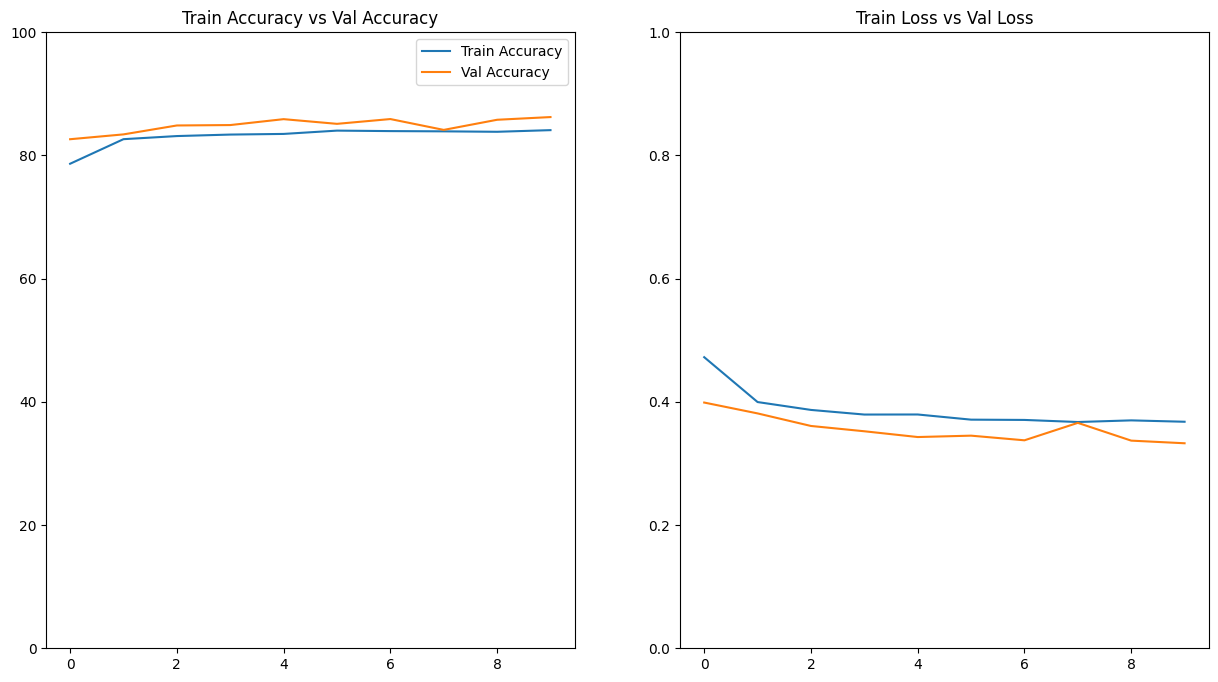

In [21]:
# Plot Train Accuracy vs Val Accuracy and Train Loss vs Val Loss
fig, axs = plt.subplots(1, 2, figsize=(15,8))
axs[0].plot(train_acc_per_epoch, label="Train Accuracy")
axs[0].plot(val_acc_per_epoch, label="Val Accuracy")
axs[0].set_title("Train Accuracy vs Val Accuracy")
axs[0].set_ylim(0, 100)
axs[0].legend()

axs[1].plot(train_loss_per_epoch, label="Train Loss")
axs[1].plot(val_loss_per_epoch, label="Val Loss")
axs[1].set_title("Train Loss vs Val Loss")
axs[1].set_ylim(0, 1)
axs[1].legend

plt.show()


## Model Testing

In [22]:
# Model in Evaluation Mode
with torch.inference_mode():
  # Evaluation Mode
  model_0.eval()

  total_test_loss = 0
  total_test_acc = 0

  for idx, data in enumerate(test_dataloader):
    x, y = data
    x = x.to(device)
    y = y.to(device)

    # Forward Pass
    predictions = model_0(x['input_ids'].squeeze(1), x['attention_mask'].squeeze(1)).squeeze(1)

    # Calculate Loss and Acc
    batch_loss = criterion(predictions, y)
    total_test_loss += batch_loss.item()
    batch_acc = accuracy_score(y.cpu().detach().numpy(), torch.round(predictions).cpu().detach().numpy())
    total_test_acc += batch_acc

  total_test_loss /= len(test_dataloader)
  total_test_acc /= len(test_dataloader)

  print(f"Test Loss: {total_test_loss} | Test Accuracy: {total_test_acc * 100}")

Test Loss: 0.3318545295014268 | Test Accuracy: 85.21825396825396
